# LMS Adaptive Filter

The LMS (Least Mean Squares) algorithm adapts an FIR filter's weights each sample to minimise the mean-square error between its output and a desired signal:

```
output[n] = wᵀ x[n]
error[n]  = desired[n] − output[n]
w         ← w + μ · error[n] · x[n]
```

`μ` (step size) controls the speed/stability trade-off: larger μ converges faster but risks divergence when μ > 2 / (N · P_x), where N is filter order and P_x is signal power.

| Function | Description |
| --- | --- |
| `lms` | Least Mean Squares (LMS) adaptive FIR filter. Returns `(output, error, weights)`. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.adaptive import lms
from python.generators import generate_sine, generate_white_noise

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Noise cancellation demonstration: a 440 Hz sine is corrupted with 30 % white noise; the same noise reference is fed to the LMS filter to cancel it.

**Three-panel stack (200 ms window):**
- **Top — noisy input:** the sine waveform buried under additive noise
- **Middle — LMS output:** the recovered sine; filter converges and noise falls after roughly 50 ms (μ = 0.005, order = 64)
- **Bottom — error signal:** starts at the noise floor level and decays toward zero as the tap weights converge

The residual noise after convergence is the *misadjustment floor*: a lower μ reduces this floor but slows convergence. Increasing the filter order captures more of the noise structure but also slows adaptation.


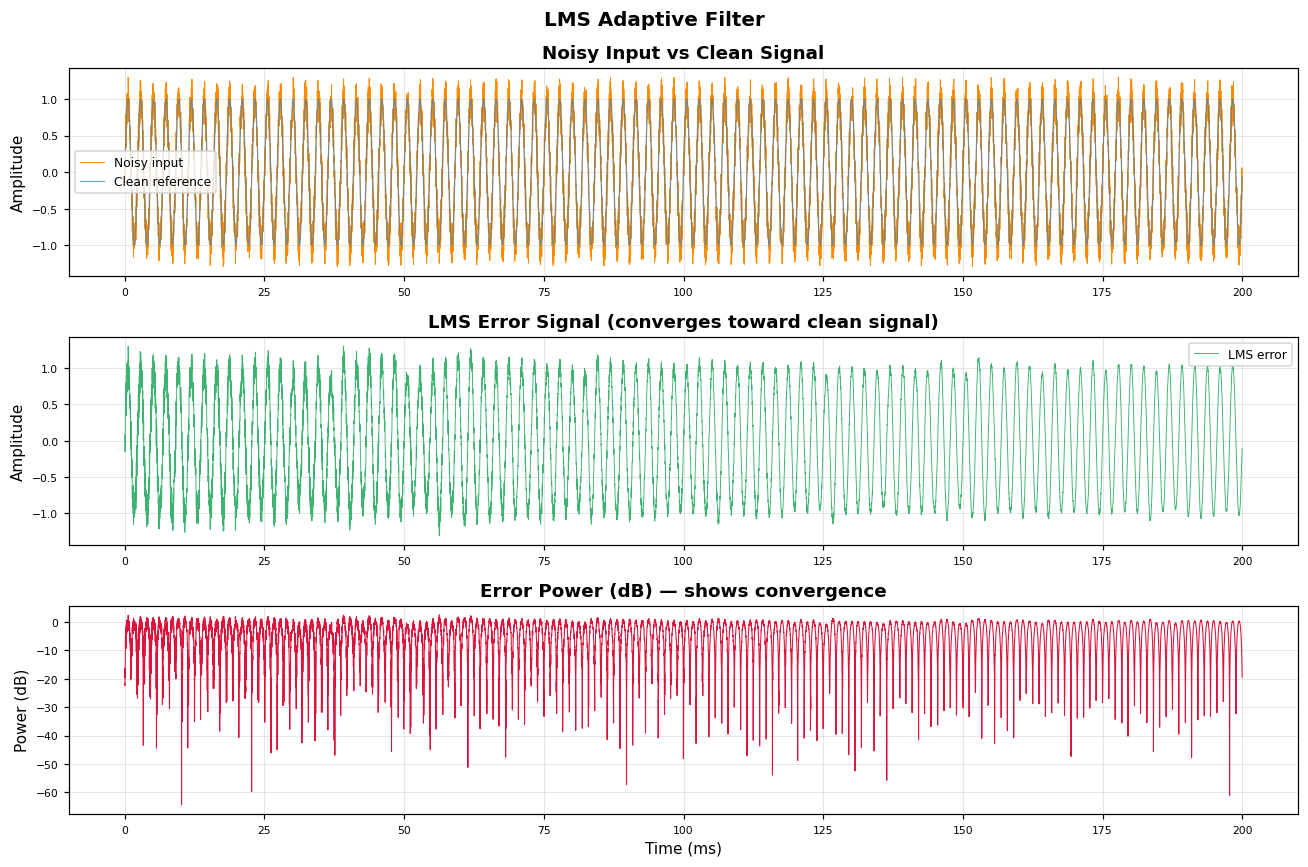

In [2]:
FS = 44100
DURATION = 0.2
FREQ = 440.0
RNG = np.random.default_rng(0)

_, clean = generate_sine(freq=FREQ, fs=FS, duration=DURATION)
_, noise = generate_white_noise(fs=FS, duration=DURATION, seed=0)

NOISE_LEVEL = 0.3
noisy = clean + NOISE_LEVEL * noise

# Use the noise reference to cancel noise from the noisy signal
output, error, weights = lms(desired=noisy, reference=NOISE_LEVEL * noise, filter_order=64, mu=0.005)

t_ms = np.arange(len(clean)) / FS * 1000

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(t_ms, noisy, linewidth=0.6, color="darkorange", label="Noisy input")
axes[0].plot(t_ms, clean, linewidth=0.8, color="steelblue", alpha=0.7, label="Clean reference")
axes[0].set_title("Noisy Input vs Clean Signal", fontweight="bold")
axes[0].set_ylabel("Amplitude")
axes[0].legend(fontsize=8)

axes[1].plot(t_ms, error, linewidth=0.6, color="mediumseagreen", label="LMS error")
axes[1].set_title("LMS Error Signal (converges toward clean signal)", fontweight="bold")
axes[1].set_ylabel("Amplitude")
axes[1].legend(fontsize=8)

error_db = 10 * np.log10(error ** 2 + 1e-20)
axes[2].plot(t_ms, error_db, linewidth=0.7, color="crimson")
axes[2].set_title("Error Power (dB) — shows convergence", fontweight="bold")
axes[2].set_ylabel("Power (dB)")
axes[2].set_xlabel("Time (ms)")

for ax in axes:
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.4, alpha=0.5)

fig.suptitle("LMS Adaptive Filter", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()